# Lines, vector fields and streamlines

Three ways to draw *directed* or *linear* geometry in 3-D:

- `lines()` — 3-D polylines (rivers, roads, trajectories), optionally classed by a column and widened.
- `vectors()` — a fixed arrow glyph at each sample of an `(N, 3)` vector field.
- `streamlines()` — integrate a dense `(nz, ny, nx, 3)` field into flow ribbons/tubes, coloured by speed.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

pv.OFF_SCREEN = True  # headless: every scene renders to an image, no interactive window

from digitalearth.base.sources import get_source
from digitalearth.three_d import Scene3D

ROOT = Path.cwd()
while not (ROOT / 'examples' / 'data' / 'LisbonElevation.tif').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / 'examples' / 'data'


def show(scene, title=''):
    """Screenshot a Scene3D off-screen and show it inline, asserting the scene area is not blank."""
    img = scene.screenshot()
    bg = img[0, 0].astype(int)
    area = img[: int(img.shape[0] * 0.8)]
    content = (np.abs(area.astype(int) - bg).sum(-1) > 30).mean()
    assert content > 0.01, f'render looks blank: only {content:.1%} differs from the background'
    plt.figure(figsize=(6, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()


def show_image(img, title=''):
    """Show an already-captured RGB frame (e.g. from a pyvista Plotter) inline."""
    plt.figure(figsize=(7, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()
import geopandas as gpd

## `lines()` — 3-D polylines coloured by a column

The Rhine river network, coloured by reach length and drawn with a wider stroke. River geometry is planar, so the scene is shown in perspective (`isometric`) to make clear it is a layer in a 3-D scene — `lines()` equally draws trajectories whose vertices carry height.

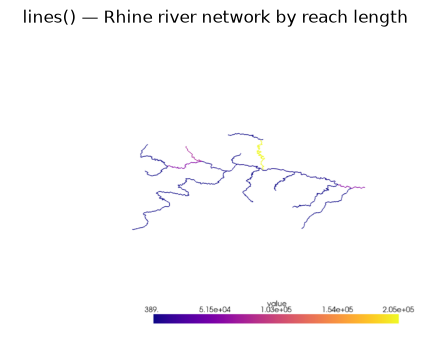

In [2]:
rivers = gpd.read_file(str(DATA / 'rhine_river_centerline.geojson'))
scene = Scene3D(off_screen=True)
scene.lines(rivers, column='Shape_Leng', cmap='plasma', width=4.0)
scene.view('isometric')
show(scene, 'lines() — Rhine river network by reach length')
scene.close()

## `vectors()` — arrow glyphs for an (N, 3) field

A genuinely 3-D field: a swirl in the x–y plane with an upward component, sampled on a grid raised through `z`. Viewed in perspective the arrows clearly live in space, not on a plane.

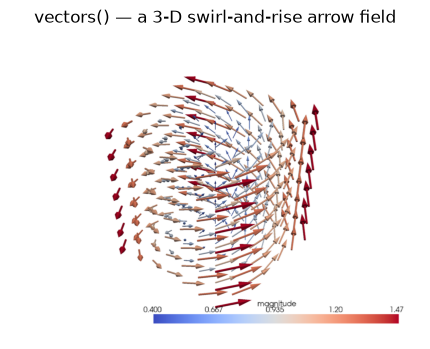

In [3]:
ax = np.linspace(-1, 1, 7)
gx, gy, gz = np.meshgrid(ax, ax, ax, indexing='ij')
pts = np.column_stack([gx.ravel(), gy.ravel(), gz.ravel()])
vecs = np.column_stack([-gy.ravel(), gx.ravel(), 0.4 * np.ones(gx.size)])  # swirl + rise
speed = np.linalg.norm(vecs, axis=1)
scene = Scene3D(off_screen=True)
scene.vectors(pts, vecs, factor=0.35, cmap='coolwarm')
scene.view('isometric')
show(scene, 'vectors() — a 3-D swirl-and-rise arrow field')
scene.close()

## `streamlines()` — trace flow through a 3-D field

A synthetic swirling field on a `(nz, ny, nx, 3)` grid: a rotation in the x–y plane with a slow rise in
`z`. `streamlines` seeds `n_points` streamers and colours each by local speed.

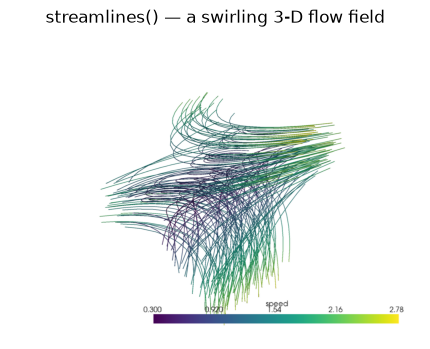

In [4]:
n = 20
ax = np.linspace(-2, 2, n)
x, y, z = np.meshgrid(ax, ax, ax, indexing='ij')
field = np.stack([-y, x, 0.3 * np.ones_like(z)], axis=-1)  # (n, n, n, 3) swirl + rise
scene = Scene3D(off_screen=True)
scene.streamlines(field, n_points=150, tube_radius=0.03, cmap='viridis')
scene.view('isometric')
show(scene, 'streamlines() — a swirling 3-D flow field')
scene.close()